In [27]:
from pathlib import Path
import sys

sys.path.append(r"D:\Users\Hannes\Documents\Python Code\nRTD\lib")

import wandb
from wandb_util import extract_run_savepoint
from nRTD.rtd_fitting_5 import RTDModule, RTDDataModule

import matplotlib.pyplot as plt
import matplotlib as mpl
import ICIW_Plots
import numpy as np
import torch


plt.style.use(["ICIWstyle"])
plt.rcParams["font.size"] = 7

In [28]:
# run_id = "jkwy4zpw" # with the shorter kernel times
run_id = "544su10u"
name, ckpt_path = extract_run_savepoint(f"ice_ulm/HSA_MGA_nRTD/{run_id}")
model = RTDModule.load_from_checkpoint(ckpt_path)
# model.net.conv_layers[0].set_to_direct_response()

E1 = model.net.E[0].numpy()
E2 = model.net.E[1].numpy()
E3 = model.net.E[2].numpy()
E4 = model.net.E[3].numpy()
t1 = model.net.conv_layers[0].t_kernel.detach().numpy()
t2 = model.net.conv_layers[1].t_kernel.detach().numpy()
t3 = model.net.conv_layers[2].t_kernel.detach().numpy()
t4 = model.net.conv_layers[3].t_kernel.detach().numpy()
delta_t = model.net.delta_t[0].item()

wandb:   1 of 1 files downloaded.  


In [29]:
print(I1 := np.trapz(E1, t1) + 1 / 2 * E1[0] * delta_t + 1 / 2 * E1[-1] * delta_t)
print(I2 := np.trapz(E2, t2) + 1 / 2 * E2[0] * delta_t + 1 / 2 * E2[-1] * delta_t)
print(I3 := np.trapz(E3, t3) + 1 / 2 * E3[0] * delta_t + 1 / 2 * E3[-1] * delta_t)
print(I4 := np.trapz(E4, t4) + 1 / 2 * E4[0] * delta_t + 1 / 2 * E4[-1] * delta_t)


print(I1 * I2 * I3 * I4)

1.0043304645332682
1.0003328053280711
0.9924781113777499
0.9970263949435321
0.9941427304010378


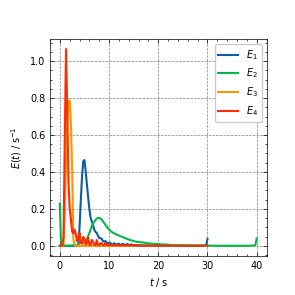

In [30]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$E(t)\;/\;\mathrm{s}^{-1}$",
)
ax.plot(t1, E1, label="$E_1$")
ax.plot(t2, E2, label="$E_2$")
ax.plot(t3, E3, label="$E_3$")
ax.plot(t4, E4, label="$E_4$")
ax.legend()

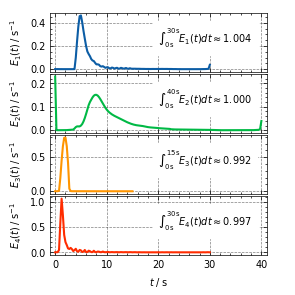

In [31]:
fig = ICIW_Plots.figure(height=7.5 * ICIW_Plots.cm2inch)
axs = ICIW_Plots.make_rect_subplots(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    ax_height=1.5 * ICIW_Plots.cm2inch,
    ax_layout=(4, 1),
    left_h=0.5,
    bottom_v=0.4,
    v_sep=0.02,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=[
        r"$E_1(t)\;/\;\mathrm{s}^{-1}$",
        r"$E_2(t)\;/\;\mathrm{s}^{-1}$",
        r"$E_3(t)\;/\;\mathrm{s}^{-1}$",
        r"$E_4(t)\;/\;\mathrm{s}^{-1}$",
    ],
    xlim=(-1, 41),
    # ylim=(-0.05, 0.65),
)
axs[0, 0].plot(t1, E1, label="$E_1$", color="C0")
axs[0, 0].text(
    x=0.5,
    y=0.5,
    s=r"$\int_{0\mathrm{s}}^{30\mathrm{s}}E_1(t)dt \approx$" + f"{I1:.3f}",
    transform=axs[0, 0].transAxes,
    backgroundcolor="white",
)
axs[1, 0].plot(t2, E2, label="$E_2$", color="C1")
axs[1, 0].text(
    x=0.5,
    y=0.5,
    s=r"$\int_{0\mathrm{s}}^{40\mathrm{s}}E_2(t)dt \approx$" + f"{I2:.3f}",
    transform=axs[1, 0].transAxes,
    backgroundcolor="white",
)
axs[2, 0].plot(t3, E3, label="$E_3$", color="C2")
axs[2, 0].text(
    x=0.5,
    y=0.5,
    s=r"$\int_{0\mathrm{s}}^{15\mathrm{s}}E_3(t)dt \approx$" + f"{I3:.3f}",
    transform=axs[2, 0].transAxes,
    backgroundcolor="white",
)
axs[3, 0].plot(t4, E4, label="$E_4$", color="C3")
axs[3, 0].text(
    x=0.5,
    y=0.5,
    s=r"$\int_{0\mathrm{s}}^{30\mathrm{s}}E_4(t)dt \approx$" + f"{I4:.3f}",
    transform=axs[3, 0].transAxes,
    backgroundcolor="white",
)
plt.savefig("all_Es_4bar_heated.png", dpi=600)

In [32]:
fig = ICIW_Plots.figure()
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    left_h=0.5,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$E(t)\;/\;\unit{\per\second}$",
    xlim=(-1, 41),
    ylim=(-0.05, 0.65),
)
ax.plot(t1, E1, label="$E_1$")
ax.plot(t2, E2, label="$E_2$")
ax.plot(t3, E3, label="$E_3$")
ax.plot(t4, E4, label="$E_4$")
ax.legend()

Error in callback <function _draw_all_if_interactive at 0x0000017022DB85E0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
E(t)\;/\;\unit{\per\second}
         ^
ParseFatalException: Unknown symbol: \unit, found '\'  (at char 9), (line:1, col:10)

ValueError: 
E(t)\;/\;\unit{\per\second}
         ^
ParseFatalException: Unknown symbol: \unit, found '\'  (at char 9), (line:1, col:10)

<Figure size 295x295 with 1 Axes>

In [33]:
t_out = (0.0, 120.0)
t_in = (0.0, 5.0)
t_halfperiod = t_out[1] - t_out[0]
n_out = int(4 * (t_out[1] - t_out[0]) + 1)
n_in = int(4 * (t_in[1] - t_in[0]) + 1)
delta_t_out = (t_out[1] - t_out[0]) / (n_out - 1)
automated_switching_times = np.full((20,), t_halfperiod)
switching_times_total_system = np.insert(automated_switching_times, 0, 7.5 - 1.0)
switching_times_total_system = np.cumsum(switching_times_total_system)

data_total_system = RTDDataModule(
    batch_size=32,
    data_file=Path(
        r"D:\Users\Hannes\Documents\Python Code\nRTD\Experiments\HSA_004\data\MGA-E-13032025_30ml-min_1atm_heated_TotalSystem.npz"
    ),
    switching_times=switching_times_total_system,
    t_range_in=t_in,
    n_in=n_in,
    t_range_out=t_out,
    n_out=n_out,
    switch_delay=1.0,
)

In [34]:
data_total_system.setup("eval")

True

In [35]:
data_total_system.y.shape

torch.Size([40, 1, 481])

In [36]:
res = model(data_total_system.x.to(torch.float), data_total_system.t_in.to(torch.float))

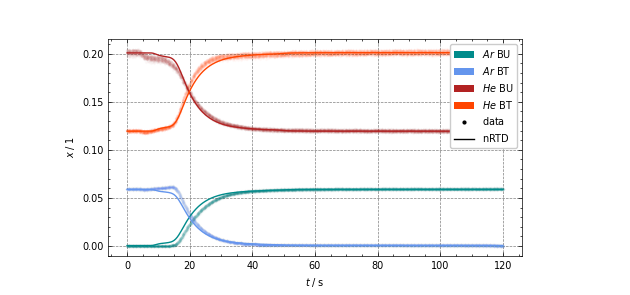

In [37]:
fig = ICIW_Plots.figure(layout="double_column")
ax = ICIW_Plots.make_rect_ax(
    fig,
    ax_height=5.5 * ICIW_Plots.cm2inch,
    ax_width=10.5 * ICIW_Plots.cm2inch,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$x \;/\; 1$",
)
ax.scatter(
    data_total_system.t_out[::4, ...],
    data_total_system.y[::4, ...],
    alpha=0.02,
    s=2,
    color="darkcyan",
    label=r"Ar BU",
)
ax.scatter(
    data_total_system.t_out[2::4, ...],
    data_total_system.y[2::4, ...],
    alpha=0.02,
    s=2,
    color="cornflowerblue",
    label=r"He BU",
)
ax.scatter(
    data_total_system.t_out[1::4, ...],
    data_total_system.y[1::4, ...],
    alpha=0.02,
    s=2,
    color="firebrick",
    label=r"Ar BT",
)
ax.scatter(
    data_total_system.t_out[3::4, ...],
    data_total_system.y[3::4, ...],
    alpha=0.02,
    s=2,
    color="orangered",
    label=r"He BT",
)

ax.plot(
    res[1][0, ...].detach().numpy(),
    res[0][0, 0, :].detach().numpy(),
    lw=1,
    color="darkcyan",
)
ax.plot(
    res[1][2, ...].detach().numpy(),
    res[0][2, 0, :].detach().numpy(),
    lw=1,
    color="cornflowerblue",
)
ax.plot(
    res[1][1, ...].detach().numpy(),
    res[0][1, 0, :].detach().numpy(),
    lw=1,
    color="firebrick",
)
ax.plot(
    res[1][3, ...].detach().numpy(),
    res[0][3, 0, :].detach().numpy(),
    lw=1,
    color="orangered",
)

legend_handles = [
    mpl.patches.Patch(facecolor="darkcyan"),
    mpl.patches.Patch(facecolor="cornflowerblue"),
    mpl.patches.Patch(facecolor="firebrick"),
    mpl.patches.Patch(facecolor="orangered"),
    plt.Line2D([0], [0], color="None", marker="o", markerfacecolor="k", markersize=2),
    plt.Line2D([0], [0], color="k", lw=1),
]
legend_names = [
    r"$Ar \text{ BU}$",
    r"$Ar \text{ BT}$",
    r"$He \text{ BU}$",
    r"$He \text{ BT}$",
    r"$\text{data}$",
    r"$\text{nRTD}$",
]

ax.legend(legend_handles, legend_names, loc="upper right")

In [38]:
normalized_signals = (data_total_system.y - data_total_system.x[:, :, [0]]) / (
    data_total_system.x[:, :, [-1]] - data_total_system.x[:, :, [0]]
)
normalized_res = (res[0] - data_total_system.x[:, :, [0]]) / (
    data_total_system.x[:, :, [-1]] - data_total_system.x[:, :, [0]]
)
print(data_total_system.y.shape)
print(normalized_signals.shape)

torch.Size([40, 1, 481])
torch.Size([40, 1, 481])


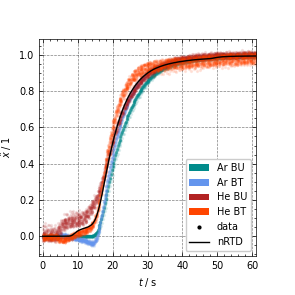

In [39]:
fig = ICIW_Plots.figure(layout="single_column")
ax = ICIW_Plots.make_square_ax(
    fig,
    ax_width=5.5 * ICIW_Plots.cm2inch,
    xlabel=r"$t \;/\; \mathrm{s}$",
    ylabel=r"$\hat{x} \;/\; 1$",
)
ax.scatter(
    data_total_system.t_out[::4, ...],
    normalized_signals[::4, ...],
    alpha=0.1,
    s=2,
    label=r"Ar BU",
    color="darkcyan",
)
ax.scatter(
    data_total_system.t_out[2::4, ...],
    normalized_signals[2::4, ...],
    alpha=0.1,
    s=2,
    label=r"He BU",
    color="cornflowerblue",
)
ax.scatter(
    data_total_system.t_out[1::4, ...],
    normalized_signals[1::4, ...],
    alpha=0.1,
    s=2,
    label=r"Ar BT",
    color="firebrick",
)
ax.scatter(
    data_total_system.t_out[3::4, ...],
    normalized_signals[3::4, ...],
    alpha=0.1,
    s=2,
    label=r"He BT",
    color="orangered",
)
ax.plot(
    res[1][0, ...].detach().numpy(),
    normalized_res[0, 0, :].detach().numpy(),
    # lw=0,
    color="black",
    label="nRTD",
    lw=1,
)
legend_handles = [
    mpl.patches.Patch(facecolor="darkcyan"),
    mpl.patches.Patch(facecolor="cornflowerblue"),
    mpl.patches.Patch(facecolor="firebrick"),
    mpl.patches.Patch(facecolor="orangered"),
    plt.Line2D([0], [0], color="None", marker="o", markerfacecolor="k", markersize=2),
    plt.Line2D([0], [0], color="k", lw=1),
]
legend_names = [
    r"Ar BU",
    r"Ar BT",
    r"He BU",
    r"He BT",
    r"data",
    r"nRTD",
]

ax.set_xlim(-1, 61)

ax.legend(legend_handles, legend_names, loc="lower right")